
# Part 1 Reliability Analysis of Accident Risk During Aircraft Landing

This notebook is a clean solution for **Part 1 only** of the airport project.

It is written to follow the **reliability-analysis methodology from the lecture slides**:

1. Define the **basic events** and their probabilities.
2. Build a **structure function** for each subsystem using **AND / OR logic**.
3. Use the lecture assumption of **independence**, except here we use the project's more specific assumption of **conditional independence given weather**.
4. Compute the subsystem risks for:
   - **wake vortex encounter**
   - **simultaneous runway occupancy**
5. Combine those two accident mechanisms into the **overall accident risk**.
6. Evaluate the **technology tradeoff levels**.
7. Explore how the answer changes as the percentage of **bad weather** increases.

---

## Interpretation used in this notebook

## <span style="color: red;">I wrote all the equations in this file in terms of AND and OR, you can rewrite them in terms of MIN and MAX for the report if you want!</span>

The project states that insufficient in-trail separation can create accident risk through **two main mechanisms**:

- wake vortex encounter
- simultaneous runway occupancy

So the overall accident event is modeled as:

$[
A = W \lor S
$]

where:

- \(W\) = wake-vortex accident event
- \(S\) = simultaneous-runway-occupancy accident event

This is exactly the sort of **system logic / structure-function** modeling emphasized in the lecture slides.

---

## Important note about climate change part

The project says that in 50 years the fraction of time with bad weather will increase, but it does **not** specify by how much.
So, instead of hard-coding one unsupported number, this notebook performs a **sensitivity analysis** over a range of bad-weather percentages.
That is usually the safest and most defensible way to answer that part unless your instructor gave a specific future percentage.


In [140]:

# ============================================================
# Imports
# ============================================================
# Only standard scientific Python tools are used.
# The notebook is intentionally kept simple and transparent.

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make tables easier to read in notebook output
#pd.set_option("display.float_format", lambda x: f"{x:.10e}")
#pd.set_option("display.float_format", lambda x: f"{x:.8f}")
pd.set_option("display.float_format", lambda x: f"{x:.2e}" if abs(x) < 1e-2 and x != 0 else f"{x:.2f}")



# 1. Enter the project data

We first store the values from the project statement.

The lecture slides emphasize that a reliability model starts by identifying the **basic components / events** and their probabilities.
Here, the "components" are the elementary events listed in the project tables.

We condition everything on weather:
- `good`
- `bad`

That matches the project statement, which says the events can be treated as **conditionally independent given the weather**.


In [157]:

# ============================================================
# Table 2: probability that the wake vortex is dangerous,
# given the sizes of the leading and trailing aircraft.
#
# The project's example says:
# heavy lead followed by small trail  -> probability 0.82
#
# That means the table should be interpreted as:
# rows    = trailing aircraft size
# columns = leading aircraft size
# ============================================================

size_mix = {
    "Heavy": 0.33,
    "Large": 0.46,
    "Small": 0.21,
}

dangerous_wake_table = pd.DataFrame(
    data=[
        [0.53, 0.44, 0.28],  # trailing Heavy, leading Heavy/Large/Small
        [0.74, 0.61, 0.41],  # trailing Large
        [0.82, 0.71, 0.59],  # trailing Small
    ],
    index=["Heavy", "Large", "Small"],    # trailing aircraft
    columns=["Heavy", "Large", "Small"],  # leading aircraft
)

dangerous_wake_table


,Heavy,Large,Small
Heavy,0.53,0.44,0.28
Large,0.74,0.61,0.41
Small,0.82,0.71,0.59


In [142]:

# ============================================================
# Tables 3 and 4 from the project
# ============================================================
# Each weather scenario gets its own dictionary of base-event
# probabilities.
#
# These are the primitive events used in the structure function.
# ============================================================

base_probs = {
    "good": {
        # Wake-vortex pathway inputs (Table 3)
        "misidentification": 2.69e-4,
        "misidentification_causes_violation": 3.82e-2,
        "misestimate_weather_effects": 5.19e-6,
        "atc_fails_to_communicate_on_time": 6.24e-5,
        "pilot_unable_to_adjust_speed": 7.23e-4,
        "pilot_unable_to_communicate_speed_problem": 1.17e-3,
        "lead_aircraft_goaround": 1.57e-4,
        "goaround_causes_violation": 2.01e-2,
        "atc_detection_system_fails": 1.95e-3,

        # Simultaneous-runway-occupancy pathway inputs (Table 4)
        "lead_cannot_leave_runway_equipment_failure": 5.12e-6,
        "lead_cannot_leave_runway_ground_congestion": 1.34e-4,
        "trailing_cannot_goaround_insufficient_reaction_time": 1.40e-3,
        "trailing_cannot_goaround_emergency": 8.36e-4,
    },
    "bad": {
        # Wake-vortex pathway inputs (Table 3)
        "misidentification": 2.69e-4,
        "misidentification_causes_violation": 3.82e-2,
        "misestimate_weather_effects": 2.33e-5,
        "atc_fails_to_communicate_on_time": 6.24e-5,
        "pilot_unable_to_adjust_speed": 4.34e-3,
        "pilot_unable_to_communicate_speed_problem": 1.17e-3,
        "lead_aircraft_goaround": 4.71e-4,
        "goaround_causes_violation": 2.01e-2,
        "atc_detection_system_fails": 1.95e-3,

        # Simultaneous-runway-occupancy pathway inputs (Table 4)
        "lead_cannot_leave_runway_equipment_failure": 5.12e-6,
        "lead_cannot_leave_runway_ground_congestion": 3.22e-4,
        "trailing_cannot_goaround_insufficient_reaction_time": 8.70e-3,
        "trailing_cannot_goaround_emergency": 8.36e-4,
    }
}

# Table 5 tradeoff values:
# (decrease in P[pilot unable to adjust speed],
#  increase in P[trailing aircraft cannot initiate go-around due to insufficient reaction time])
tradeoff_table = {
    1:  (0.00e-4,  0.0e-6),
    2:  (3.63e-4,  1.0e-6),
    3:  (4.68e-4,  2.0e-6),
    4:  (4.88e-4,  3.0e-6),
    5:  (4.94e-4,  4.0e-6),
    6:  (4.96e-4,  5.0e-6),
    7:  (5.03e-4,  6.0e-6),
    8:  (5.08e-4,  7.0e-6),
    9:  (5.11e-4,  8.0e-6),
    10: (5.14e-4,  9.0e-6),
    11: (5.17e-4, 10.0e-6),
}

pd.DataFrame(tradeoff_table, index=["speed_adjustment_decrease", "goaround_reaction_increase"]).T


,speed_adjustment_decrease,goaround_reaction_increase
1,0.00,0.00
2,3.63e-04,1.00e-06
3,4.68e-04,2.00e-06
4,4.88e-04,3.00e-06
5,4.94e-04,4.00e-06
6,4.96e-04,5.00e-06
7,5.03e-04,6.00e-06
8,5.08e-04,7.00e-06
9,5.11e-04,8.00e-06
10,5.14e-04,9.00e-06



# 2. Compute the probability of a dangerous wake vortex

The project gives:
- the aircraft size mix
- the probability that a wake vortex is dangerous for each lead/trail size pair

So the probability of a dangerous wake vortex is the weighted average over all lead/trail combinations:

$[
P(D) = \sum_{\text{trail}} \sum_{\text{lead}}
P(\text{trail size}) P(\text{lead size}) P(D \mid \text{trail, lead})
$]

This is a straightforward expectation calculation.


In [161]:

# ============================================================
# Compute P(dangerous wake vortex)
# ============================================================
# We assume the size of the leading and trailing aircraft are
# independent draws from the given arrival-size mix.
# ============================================================

dangerous_wake_probability = 0.0

for trailing_size, p_trailing in size_mix.items():
    for leading_size, p_leading in size_mix.items():
        pair_probability = p_trailing * p_leading
        conditional_danger = dangerous_wake_table.loc[trailing_size, leading_size]
        dangerous_wake_probability += pair_probability * conditional_danger

print(f"Probability of a dangerous wake vortex = {dangerous_wake_probability} = {dangerous_wake_probability * 100:.4f}%")
#dangerous_wake_probability


Probability of a dangerous wake vortex = 0.576358 = 57.6358%



# 3. Reliability building blocks

The lecture slides emphasize working with a **structure function**.

For independent events:
- AND of events becomes a **product**
- OR of events becomes **one minus the product of complements**

So we define a helper for OR:

$[
P(E_1 \cup E_2 \cup \cdots \cup E_n) = 1 - \prod_{i=1}^{n} (1 - P(E_i))
$]

We will use that repeatedly below.


In [144]:

# ============================================================
# Helper functions for reliability calculations
# ============================================================

def prob_or(*probabilities):
    """Probability that at least one independent event occurs."""
    product_of_complements = 1.0
    for p in probabilities:
        product_of_complements *= (1.0 - p)
    return 1.0 - product_of_complements


def probability_weighted_by_weather(prob_good, prob_bad, p_bad):
    """Combine conditional probabilities using the law of total probability."""
    p_good = 1.0 - p_bad
    return p_good * prob_good + p_bad * prob_bad



# 4. Build the structure functions

## 4.1 Wake-vortex encounter logic

From the project statement, an in-trail separation violation can happen through three branches:

1. **Air traffic control branch**
2. **Trailing aircraft branch**
3. **Leading aircraft go-around branch**

### Air traffic control branch
A violation happens if **any** of these occurs:
- aircraft misidentification **and** that misidentification causes a violation
- misestimate of weather effects
- failure to communicate on time

So:

$[
A_{\text{ATC}} = (M \land MV) \lor W \lor C 
$]

### Trailing aircraft branch
A violation occurs if:
- pilot cannot adjust speed
- and the pilot also cannot communicate that problem back promptly

$[
A_{\text{trail}} = S \land U
$]

### Leading aircraft branch
A violation occurs if:
- the lead aircraft must go around
- and that go-around causes a separation violation

$[
A_{\text{lead}} = G \land GV
$]

### Any separation violation
$[
V = A_{\text{ATC}} \lor A_{\text{trail}} \lor A_{\text{lead}}
$]

### Wake-vortex accident event
For a wake-vortex accident, we need:
- a dangerous wake vortex exists
- a separation violation occurs
- the ATC detection/correction system fails

$[
W = D \land V \land F
$]

---

## 4.2 Simultaneous runway occupancy logic

For simultaneous runway occupancy:

### Lead aircraft branch
The lead aircraft fails to vacate the runway if:
- equipment failure
- or ground congestion

$[
L = E \lor G
$]

### Trailing aircraft branch
The trailing aircraft cannot avoid the runway occupancy if it cannot go around because of:
- insufficient reaction time
- or emergency

$[
T = R \lor EM
$]

### Simultaneous runway occupancy event
$[
S = L \land T
$]

---

## 4.3 Overall accident logic

The project says insufficient in-trail separation creates accident risk due to two main reasons:
- wake vortex encounter
- simultaneous runway occupancy

So the overall accident event is:

$[
A = W \lor S
$]

That is the final top-level structure function.


In [ ]:

# ============================================================
# Core reliability model
# ============================================================
# This function computes the full accident-risk breakdown for one
# weather scenario and one technology tradeoff level.
#
# The comments directly mirror the project statement and the
# lecture structure-function methodology.
# ============================================================

def compute_risk_given_weather(weather, tradeoff_level=1):
    """
    Compute all intermediate and final probabilities for one weather condition.

    Parameters
    ----------
    weather : str
        Either "good" or "bad".
    tradeoff_level : int
        Integer from 1 to 11.

    Returns
    -------
    dict
        Dictionary containing intermediate branch probabilities
        and final risk measures.
    """
    # Copy the base probabilities so we can modify them safely
    p = dict(base_probs[weather])

    # Apply the technology tradeoff
    #
    # The project says the technology reduces the probability that the
    # pilot cannot adjust speed, but relaxing separation standards can
    # increase the probability that the trailing aircraft cannot begin
    # the go-around because of insufficient reaction time.
    decrease_speed_failure, increase_reaction_failure = tradeoff_table[tradeoff_level]

    p["pilot_unable_to_adjust_speed"] -= decrease_speed_failure
    p["trailing_cannot_goaround_insufficient_reaction_time"] += increase_reaction_failure

    # -----------------------------
    # WAKE-VORTEX SUBSYSTEM
    # -----------------------------

    # ATC branch:
    # (misidentification AND it causes a violation) OR
    # misestimate weather effects OR
    # late ATC communication
    atc_branch = prob_or(
        p["misidentification"] * p["misidentification_causes_violation"],
        p["misestimate_weather_effects"],
        p["atc_fails_to_communicate_on_time"],
    )

    # Trailing-aircraft branch:
    # pilot cannot adjust speed AND cannot communicate that problem back
    trailing_branch = (
        p["pilot_unable_to_adjust_speed"]
        * p["pilot_unable_to_communicate_speed_problem"]
    )

    # Leading-aircraft branch:
    # lead goes around AND that go-around causes a violation
    leading_branch = (
        p["lead_aircraft_goaround"]
        * p["goaround_causes_violation"]
    )

    # Any separation violation
    separation_violation = prob_or(
        atc_branch,
        trailing_branch,
        leading_branch,
    )

    # Wake-vortex accident:
    # dangerous wake exists AND separation is violated AND detection fails
    wake_vortex_risk = (
        dangerous_wake_probability
        * separation_violation
        * p["atc_detection_system_fails"]
    )

    # -----------------------------
    # SIMULTANEOUS RUNWAY OCCUPANCY SUBSYSTEM
    # -----------------------------

    # Lead aircraft fails to vacate runway:
    # equipment failure OR ground congestion
    lead_fails_to_vacate = prob_or(
        p["lead_cannot_leave_runway_equipment_failure"],
        p["lead_cannot_leave_runway_ground_congestion"],
    )

    # Trailing aircraft cannot go around:
    # insufficient reaction time OR emergency
    trailing_cannot_goaround = prob_or(
        p["trailing_cannot_goaround_insufficient_reaction_time"],
        p["trailing_cannot_goaround_emergency"],
    )

    # Simultaneous runway occupancy:
    # lead does not clear runway AND trailing cannot avoid it
    simultaneous_runway_occupancy_risk = (lead_fails_to_vacate * trailing_cannot_goaround)

    # -----------------------------
    # OVERALL ACCIDENT RISK
    # -----------------------------
    # Accident occurs if either mechanism occurs:
    # wake-vortex accident OR simultaneous runway occupancy accident
    overall_accident_risk = prob_or(
        wake_vortex_risk,
        simultaneous_runway_occupancy_risk,
    )

    return {
        "weather": weather,
        "tradeoff_level": tradeoff_level,
        "dangerous_wake_probability": dangerous_wake_probability,
        "atc_branch": atc_branch,
        "trailing_branch": trailing_branch,
        "leading_branch": leading_branch,
        "separation_violation": separation_violation,
        "wake_vortex_risk": wake_vortex_risk,
        "lead_fails_to_vacate": lead_fails_to_vacate,
        "trailing_cannot_goaround": trailing_cannot_goaround,
        "simultaneous_runway_occupancy_risk": simultaneous_runway_occupancy_risk,
        "overall_accident_risk": overall_accident_risk,
    }



# 5. Baseline results for good weather versus bad weather

This directly answers the first project objective:
> Calculate and compare the overall accident risk when the weather is good versus when the weather is bad.

We start with **tradeoff level 1**, which is the no-relaxation / no-extra-tradeoff baseline from Table 5.


In [146]:

# ============================================================
# Baseline good-weather and bad-weather results
# ============================================================

baseline_good = compute_risk_given_weather("good", tradeoff_level=1)
baseline_bad = compute_risk_given_weather("bad", tradeoff_level=1)

baseline_df = pd.DataFrame([baseline_good, baseline_bad]).set_index("weather")
baseline_df[[
    "dangerous_wake_probability",
    "atc_branch",
    "trailing_branch",
    "leading_branch",
    "separation_violation",
    "wake_vortex_risk",
    "lead_fails_to_vacate",
    "trailing_cannot_goaround",
    "simultaneous_runway_occupancy_risk",
    "overall_accident_risk",
]]


,dangerous_wake_probability,atc_branch,trailing_branch,leading_branch,separation_violation,wake_vortex_risk,lead_fails_to_vacate,trailing_cannot_goaround,simultaneous_runway_occupancy_risk,overall_accident_risk
weather,,,,,,,,,,
good,0.58,7.79e-05,8.46e-07,3.16e-06,8.19e-05,9.20e-08,1.39e-04,2.23e-03,3.11e-07,4.03e-07
bad,0.58,9.60e-05,5.08e-06,9.47e-06,1.11e-04,1.24e-07,3.27e-04,9.53e-03,3.12e-06,3.24e-06


In [147]:

# A simpler summary table for the report
summary_good_bad = pd.DataFrame({
    "metric": [
        "Wake-vortex risk",
        "Simultaneous runway occupancy risk",
        "Overall accident risk",
    ],
    "Good weather": [
        baseline_good["wake_vortex_risk"],
        baseline_good["simultaneous_runway_occupancy_risk"],
        baseline_good["overall_accident_risk"],
    ],
    "Bad weather": [
        baseline_bad["wake_vortex_risk"],
        baseline_bad["simultaneous_runway_occupancy_risk"],
        baseline_bad["overall_accident_risk"],
    ],
})

summary_good_bad


,metric,Good weather,Bad weather
0,Wake-vortex risk,9.20e-08,1.24e-07
1,Simultaneous runway occupancy risk,3.11e-07,3.12e-06
2,Overall accident risk,4.03e-07,3.24e-06



# 6. Evaluate the new technology under the 80% good / 20% bad weather mix

Now we answer the second project objective.

The project says:
- weather is good 80% of the time
- weather is bad 20% of the time

So for each tradeoff level, the unconditional accident risk is:

$[
P(A) = 0.8 \, P(A \mid \text{good}) + 0.2 \, P(A \mid \text{bad})
$]

We calculate this for all 11 levels and then choose the level with the **minimum overall accident risk**.


In [148]:

# ============================================================
# Evaluate all tradeoff levels under the 80/20 weather mix
# ============================================================

def compute_mixed_weather_results(p_bad=0.20):
    """
    Compute accident risk for each tradeoff level under a specified
    fraction of bad weather.
    """
    rows = []

    for level in sorted(tradeoff_table.keys()):
        good = compute_risk_given_weather("good", tradeoff_level=level)
        bad = compute_risk_given_weather("bad", tradeoff_level=level)

        mixed_wake = probability_weighted_by_weather(
            good["wake_vortex_risk"],
            bad["wake_vortex_risk"],
            p_bad,
        )
        mixed_sro = probability_weighted_by_weather(
            good["simultaneous_runway_occupancy_risk"],
            bad["simultaneous_runway_occupancy_risk"],
            p_bad,
        )
        mixed_total = probability_weighted_by_weather(
            good["overall_accident_risk"],
            bad["overall_accident_risk"],
            p_bad,
        )

        rows.append({
            "tradeoff_level": level,
            "bad_weather_fraction": p_bad,
            "good_weather_fraction": 1.0 - p_bad,
            "wake_vortex_risk_mixed": mixed_wake,
            "sro_risk_mixed": mixed_sro,
            "overall_accident_risk_mixed": mixed_total,
            "good_weather_total_risk": good["overall_accident_risk"],
            "bad_weather_total_risk": bad["overall_accident_risk"],
        })

    results = pd.DataFrame(rows)
    return results


results_80_20 = compute_mixed_weather_results(p_bad=0.20)
results_80_20


,tradeoff_level,bad_weather_fraction,good_weather_fraction,wake_vortex_risk_mixed,sro_risk_mixed,overall_accident_risk_mixed,good_weather_total_risk,bad_weather_total_risk
0,1,0.20,0.80,9.84e-08,8.72e-07,9.71e-07,4.03e-07,3.24e-06
1,2,0.20,0.80,9.80e-08,8.72e-07,9.70e-07,4.03e-07,3.24e-06
2,3,0.20,0.80,9.78e-08,8.72e-07,9.70e-07,4.03e-07,3.24e-06
3,4,0.20,0.80,9.78e-08,8.73e-07,9.70e-07,4.03e-07,3.24e-06
4,5,0.20,0.80,9.78e-08,8.73e-07,9.71e-07,4.03e-07,3.24e-06
5,6,0.20,0.80,9.78e-08,8.73e-07,9.71e-07,4.03e-07,3.24e-06
6,7,0.20,0.80,9.78e-08,8.73e-07,9.71e-07,4.03e-07,3.24e-06
7,8,0.20,0.80,9.78e-08,8.73e-07,9.71e-07,4.03e-07,3.24e-06
8,9,0.20,0.80,9.78e-08,8.74e-07,9.71e-07,4.03e-07,3.24e-06
9,10,0.20,0.80,9.78e-08,8.74e-07,9.71e-07,4.03e-07,3.24e-06


In [149]:

# Identify the optimal tradeoff level under the baseline 80/20 weather mix
best_row_80_20 = results_80_20.loc[
    results_80_20["overall_accident_risk_mixed"].idxmin()
]

best_row_80_20


tradeoff_level                    2.00
bad_weather_fraction              0.20
good_weather_fraction             0.80
wake_vortex_risk_mixed        9.80e-08
sro_risk_mixed                8.72e-07
overall_accident_risk_mixed   9.70e-07
good_weather_total_risk       4.03e-07
bad_weather_total_risk        3.24e-06
Name: 1, dtype: float64

In [150]:

# A compact ranking table from best to worst
ranking_80_20 = results_80_20.sort_values("overall_accident_risk_mixed").reset_index(drop=True)
ranking_80_20


,tradeoff_level,bad_weather_fraction,good_weather_fraction,wake_vortex_risk_mixed,sro_risk_mixed,overall_accident_risk_mixed,good_weather_total_risk,bad_weather_total_risk
0,2,0.20,0.80,9.80e-08,8.72e-07,9.70e-07,4.03e-07,3.24e-06
1,3,0.20,0.80,9.78e-08,8.72e-07,9.70e-07,4.03e-07,3.24e-06
2,4,0.20,0.80,9.78e-08,8.73e-07,9.70e-07,4.03e-07,3.24e-06
3,1,0.20,0.80,9.84e-08,8.72e-07,9.71e-07,4.03e-07,3.24e-06
4,5,0.20,0.80,9.78e-08,8.73e-07,9.71e-07,4.03e-07,3.24e-06
5,6,0.20,0.80,9.78e-08,8.73e-07,9.71e-07,4.03e-07,3.24e-06
6,7,0.20,0.80,9.78e-08,8.73e-07,9.71e-07,4.03e-07,3.24e-06
7,8,0.20,0.80,9.78e-08,8.73e-07,9.71e-07,4.03e-07,3.24e-06
8,9,0.20,0.80,9.78e-08,8.74e-07,9.71e-07,4.03e-07,3.24e-06
9,10,0.20,0.80,9.78e-08,8.74e-07,9.71e-07,4.03e-07,3.24e-06


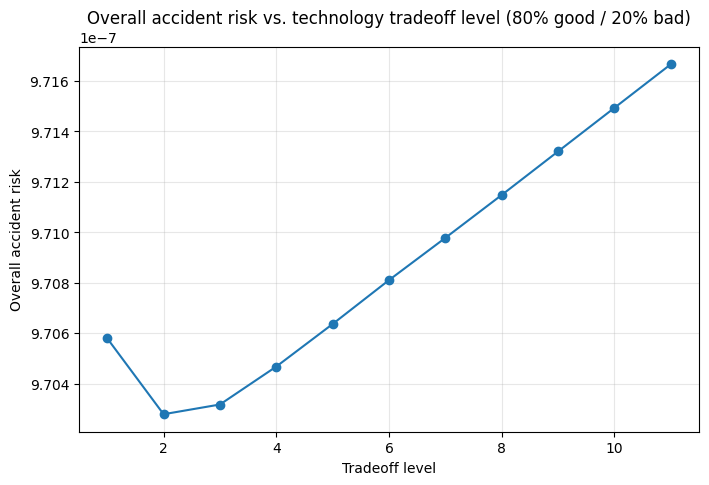

In [151]:

# Plot risk versus tradeoff level under the 80/20 mix
plt.figure(figsize=(8, 5))
plt.plot(
    results_80_20["tradeoff_level"],
    results_80_20["overall_accident_risk_mixed"],
    marker="o",
)
plt.xlabel("Tradeoff level")
plt.ylabel("Overall accident risk")
plt.title("Overall accident risk vs. technology tradeoff level (80% good / 20% bad)")
plt.grid(True, alpha=0.3)
plt.show()



# 7. Climate-change sensitivity analysis

The project says that in 50 years the percentage of time with bad weather is expected to increase.

Because no single future percentage is provided, we examine a whole range of values for the bad-weather fraction:
- 0%
- 5%
- 10%
- ...
- 100%

This allows us to answer:
- how the overall risk changes as bad weather becomes more common
- whether the **optimal tradeoff level** changes


In [165]:

# ============================================================
# Sensitivity analysis over the bad-weather fraction
# ============================================================

sensitivity_rows = []

for p_bad in np.linspace(0.0, 1.0, 21):  # 0%, 5%, ..., 100%
    mixed_results = compute_mixed_weather_results(p_bad=p_bad)
    best_index = mixed_results["overall_accident_risk_mixed"].idxmin()
    best_row = mixed_results.loc[best_index]

    sensitivity_rows.append({
        "bad_weather_fraction": p_bad,
        "good_weather_fraction": 1.0 - p_bad,
        "optimal_tradeoff_level": int(best_row["tradeoff_level"]),
        "minimum_overall_accident_risk": best_row["overall_accident_risk_mixed"],
    })

sensitivity_df = pd.DataFrame(sensitivity_rows)
sensitivity_df


,bad_weather_fraction,good_weather_fraction,optimal_tradeoff_level,minimum_overall_accident_risk
0,0.00,1.00,2,4.03e-07
1,0.05,0.95,2,5.45e-07
2,0.10,0.90,2,6.86e-07
3,0.15,0.85,2,8.28e-07
4,0.20,0.80,2,9.70e-07
5,0.25,0.75,2,1.11e-06
6,0.30,0.70,2,1.25e-06
7,0.35,0.65,2,1.40e-06
8,0.40,0.60,2,1.54e-06
9,0.45,0.55,2,1.68e-06


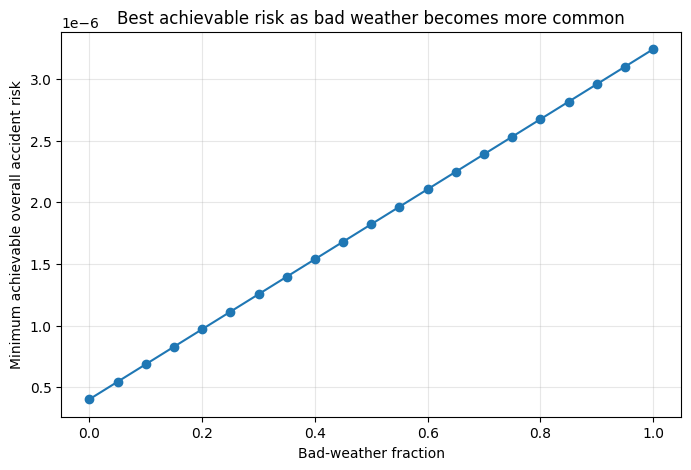

In [ ]:

# Plot of the minimum achievable accident risk as bad weather becomes more common
plt.figure(figsize=(8, 5))
plt.plot(
    sensitivity_df["bad_weather_fraction"],
    sensitivity_df["minimum_overall_accident_risk"],
    marker="o",
)
plt.xlabel("Bad-weather fraction")
plt.ylabel("Minimum achievable overall accident risk")
plt.title("Best achievable risk as bad weather becomes more common")
plt.grid(True, alpha=0.3)
plt.show()


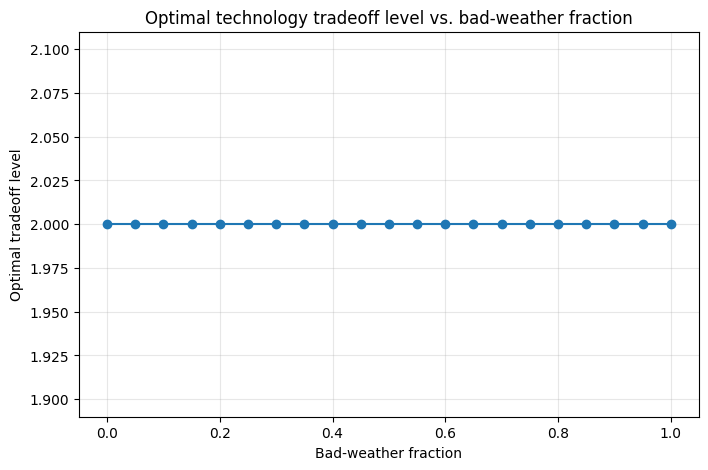

In [ ]:

# Plot of the optimal tradeoff level as bad weather becomes more common
plt.figure(figsize=(8, 5))
plt.plot(
    sensitivity_df["bad_weather_fraction"],
    sensitivity_df["optimal_tradeoff_level"],
    marker="o",
)
plt.xlabel("Bad-weather fraction")
plt.ylabel("Optimal tradeoff level")
plt.title("Optimal technology tradeoff level vs. bad-weather fraction")
plt.grid(True, alpha=0.3)
plt.show()



# 8. Final answer summary

The cell below prints a concise text summary that can be used as the backbone of your written discussion.


In [163]:

# ============================================================
# Human-readable summary
# ============================================================

print("Probability that the wake vortex is dangerous:", f"{dangerous_wake_probability:.10e}")
print()

print("BASELINE COMPARISON (tradeoff level 1)")
print("Good-weather overall accident risk:", f"{baseline_good['overall_accident_risk']:.10e}")
print("Bad-weather overall accident risk :", f"{baseline_bad['overall_accident_risk']:.10e}")
print()

print("TECHNOLOGY OPTIMIZATION UNDER 80% GOOD / 20% BAD WEATHER")
print("Optimal tradeoff level:", int(best_row_80_20["tradeoff_level"]))
print("Minimum overall accident risk:", f"{best_row_80_20['overall_accident_risk_mixed']:.10e}")
print()

unique_optima = sensitivity_df["optimal_tradeoff_level"].unique()
print("CLIMATE-CHANGE SENSITIVITY")
print("Optimal tradeoff levels observed over the sensitivity analysis:", unique_optima)
if len(unique_optima) == 1:
    print(
        f"The optimal tradeoff level stays constant at level {int(unique_optima[0])} "
        "over the tested range of bad-weather fractions."
    )
else:
    print("The optimal tradeoff level changes as the bad-weather fraction increases.")


Probability that the wake vortex is dangerous: 5.7635800000e-01

BASELINE COMPARISON (tradeoff level 1)
Good-weather overall accident risk: 4.0291706083e-07
Bad-weather overall accident risk : 3.2412307722e-06

TECHNOLOGY OPTIMIZATION UNDER 80% GOOD / 20% BAD WEATHER
Optimal tradeoff level: 2
Minimum overall accident risk: 9.7027908521e-07

CLIMATE-CHANGE SENSITIVITY
Optimal tradeoff levels observed over the sensitivity analysis: [2]
The optimal tradeoff level stays constant at level 2 over the tested range of bad-weather fractions.



# 9. Interpretation notes to mention in the submission

1. **Bad weather substantially increases accident risk.**  
   In this model, the increase is especially strong through the simultaneous-runway-occupancy pathway because bad weather greatly increases the probability of insufficient reaction time and also increases some other relevant event probabilities.

2. **The reliability methodology follows the lecture slides.**  
   The model is built using explicit **structure functions** with AND/OR combinations of elementary events, rather than by averaging event probabilities.

3. **The technology should be chosen using the final accident risk, not a local "benefit minus cost" score.**  
   The correct optimization criterion is the overall accident probability after all reliability logic is propagated through the system.

4. **For the climate-change part, a sensitivity analysis is the most defensible answer unless a specific future bad-weather percentage is provided.**

5. **Affect on Optimal Tradeoff in New Technology**
   As the fraction of bad weather increases, we can see that the optimal tradeoff level reamins level 2. The major difference we can see is that when the weather conditions become as bad as it can get at 100% of the time, the overall accident risk probability becomes 3.24e-6 which is where the baseline overall risk probability for bad weather was at without the new technology addition. Meaning the tradeoff the new technology affected really makes a difference in overall accident risk as having bad weather 100% of the time is not that probable.
